# Exploratory Data Analysis — Credit Card Fraud Detection

**Dataset:** 284,807 transactions with 492 fraudulent cases (0.17% fraud rate)  
**Goal:** Understand the data distribution, class imbalance, and feature patterns before training any models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/raw/creditcard.csv'

## 1. Load the Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape: (284807, 31)
Memory: 70.6 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe().round(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


## 2. Missing Values

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values — dataset is clean.')

Missing values per column:
No missing values — dataset is clean.


## 3. Class Imbalance

This is the most critical insight: fraud is extremely rare. A naive model that always predicts 'not fraud' would be 99.83% accurate — but completely useless.

In [6]:
counts = df['Class'].value_counts()
pct    = df['Class'].value_counts(normalize=True) * 100

print('Class Distribution')
print('-' * 35)
print(f'Normal transactions : {counts[0]:>7,}  ({pct[0]:.4f}%)')
print(f'Fraud  transactions : {counts[1]:>7,}  ({pct[1]:.4f}%)')
print(f'Total               : {len(df):>7,}')
print(f'\nImbalance ratio     : {counts[0] / counts[1]:.0f}:1  (normal:fraud)')

Class Distribution
-----------------------------------
Normal transactions : 284,315  (99.8273%)
Fraud  transactions :     492  (0.1727%)
Total               : 284,807

Imbalance ratio     : 578:1  (normal:fraud)


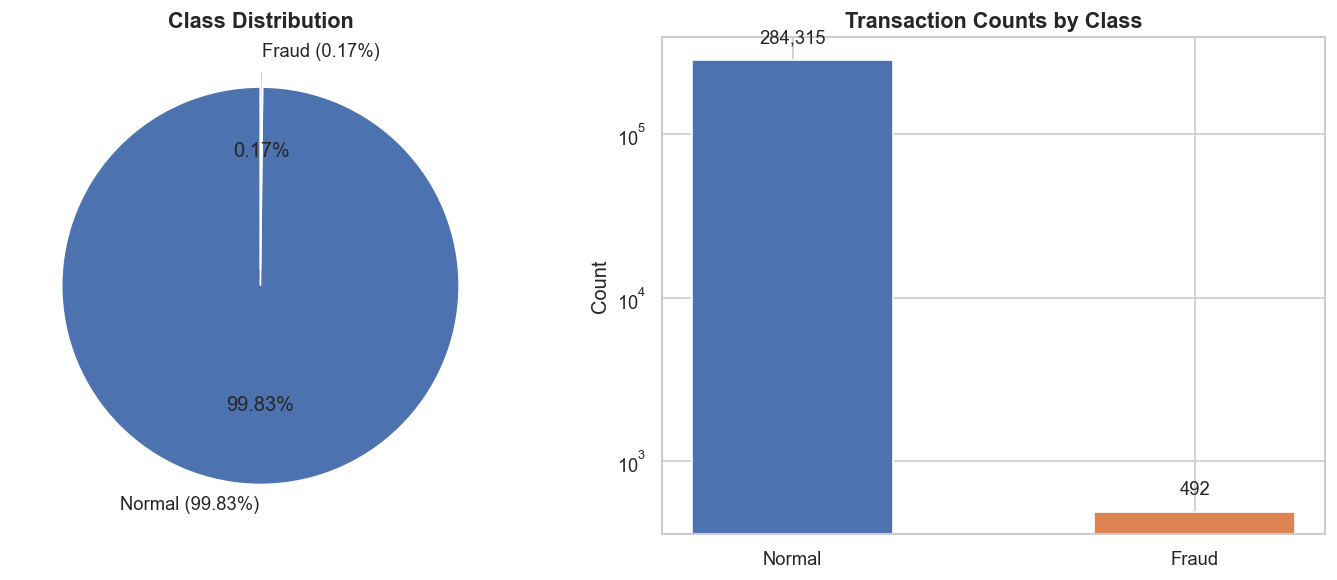

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    counts,
    labels=['Normal (99.83%)', 'Fraud (0.17%)'],
    colors=['#4C72B0', '#DD8452'],
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.08)
)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(['Normal', 'Fraud'], counts.values, color=['#4C72B0', '#DD8452'], width=0.5)
axes[1].set_title('Transaction Counts by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.2,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../data/raw/class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Transaction Amount Analysis

In [8]:
print('Amount statistics by class:')
df.groupby('Class')['Amount'].describe().round(2)

Amount statistics by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


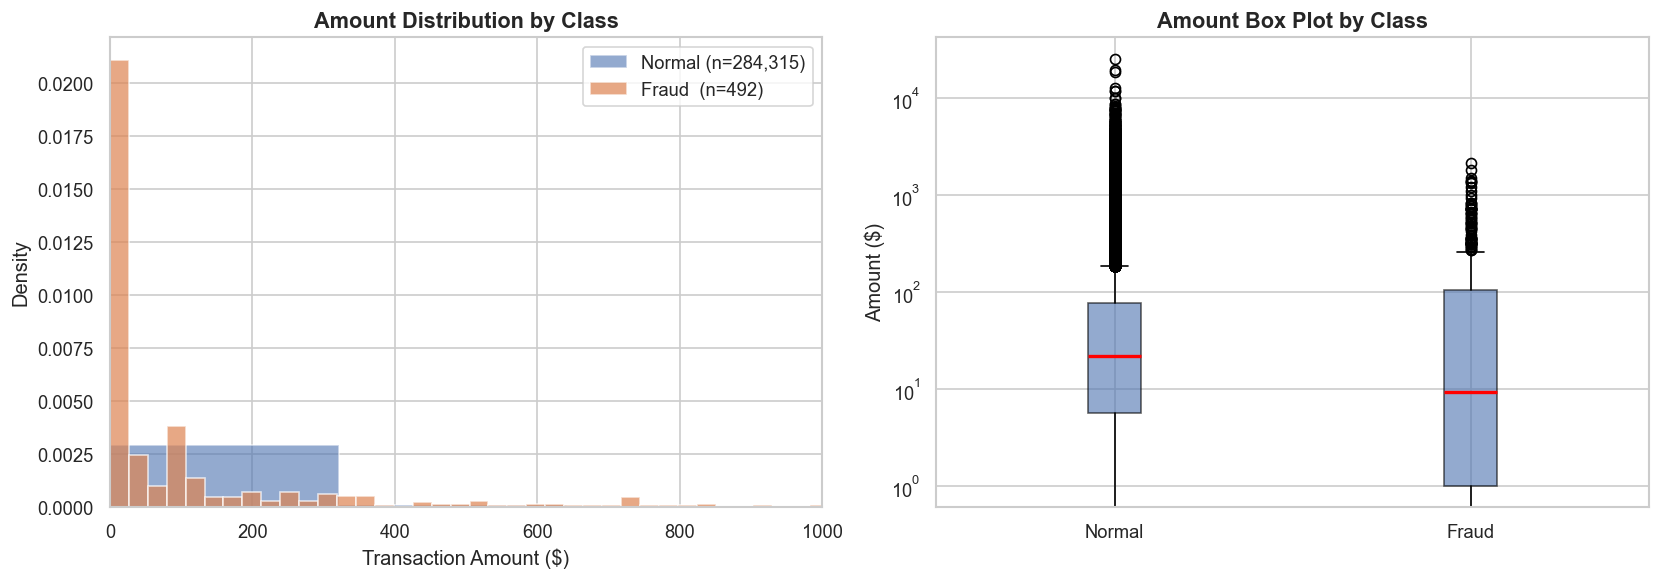

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal = df[df['Class'] == 0]['Amount']
fraud  = df[df['Class'] == 1]['Amount']

# Distribution
axes[0].hist(normal, bins=80, alpha=0.6, color='#4C72B0', label=f'Normal (n={len(normal):,})', density=True)
axes[0].hist(fraud,  bins=80, alpha=0.7, color='#DD8452', label=f'Fraud  (n={len(fraud):,})',  density=True)
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution by Class', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1000)
axes[0].legend()

# Box plot
axes[1].boxplot([normal, fraud], labels=['Normal', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Amount ($)')
axes[1].set_title('Amount Box Plot by Class', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 5. Time Feature Analysis

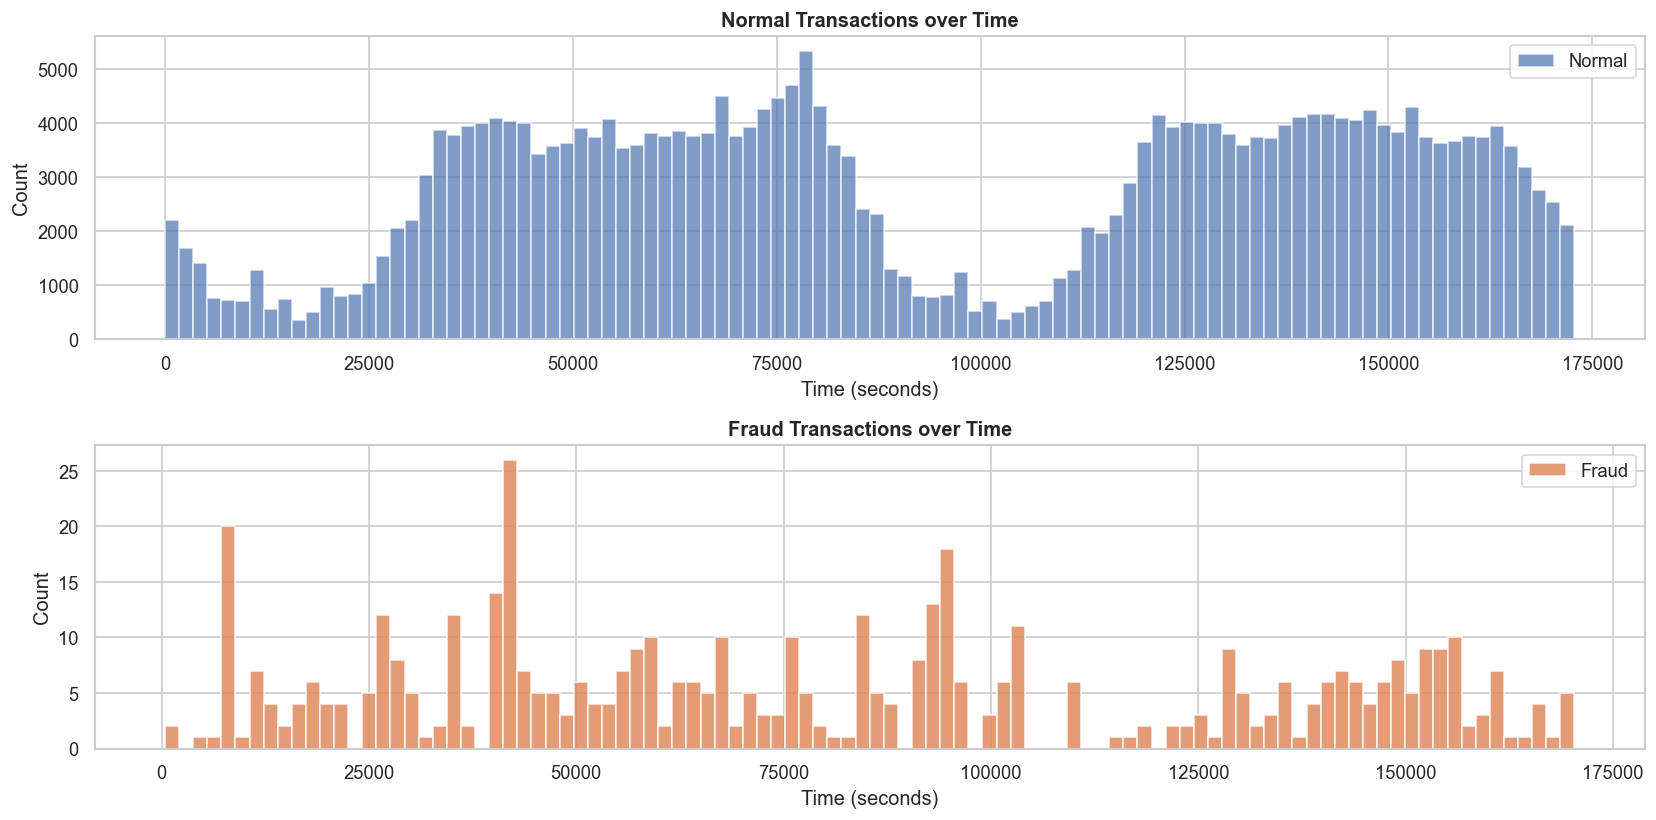

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].hist(df[df['Class'] == 0]['Time'], bins=100, color='#4C72B0', alpha=0.7, label='Normal')
axes[0].set_title('Normal Transactions over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df[df['Class'] == 1]['Time'], bins=100, color='#DD8452', alpha=0.8, label='Fraud')
axes[1].set_title('Fraud Transactions over Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Feature Distributions — V1 to V28

These are PCA-transformed features. We compare their distributions between fraud and normal transactions to see which features have the most separation (useful for classification).

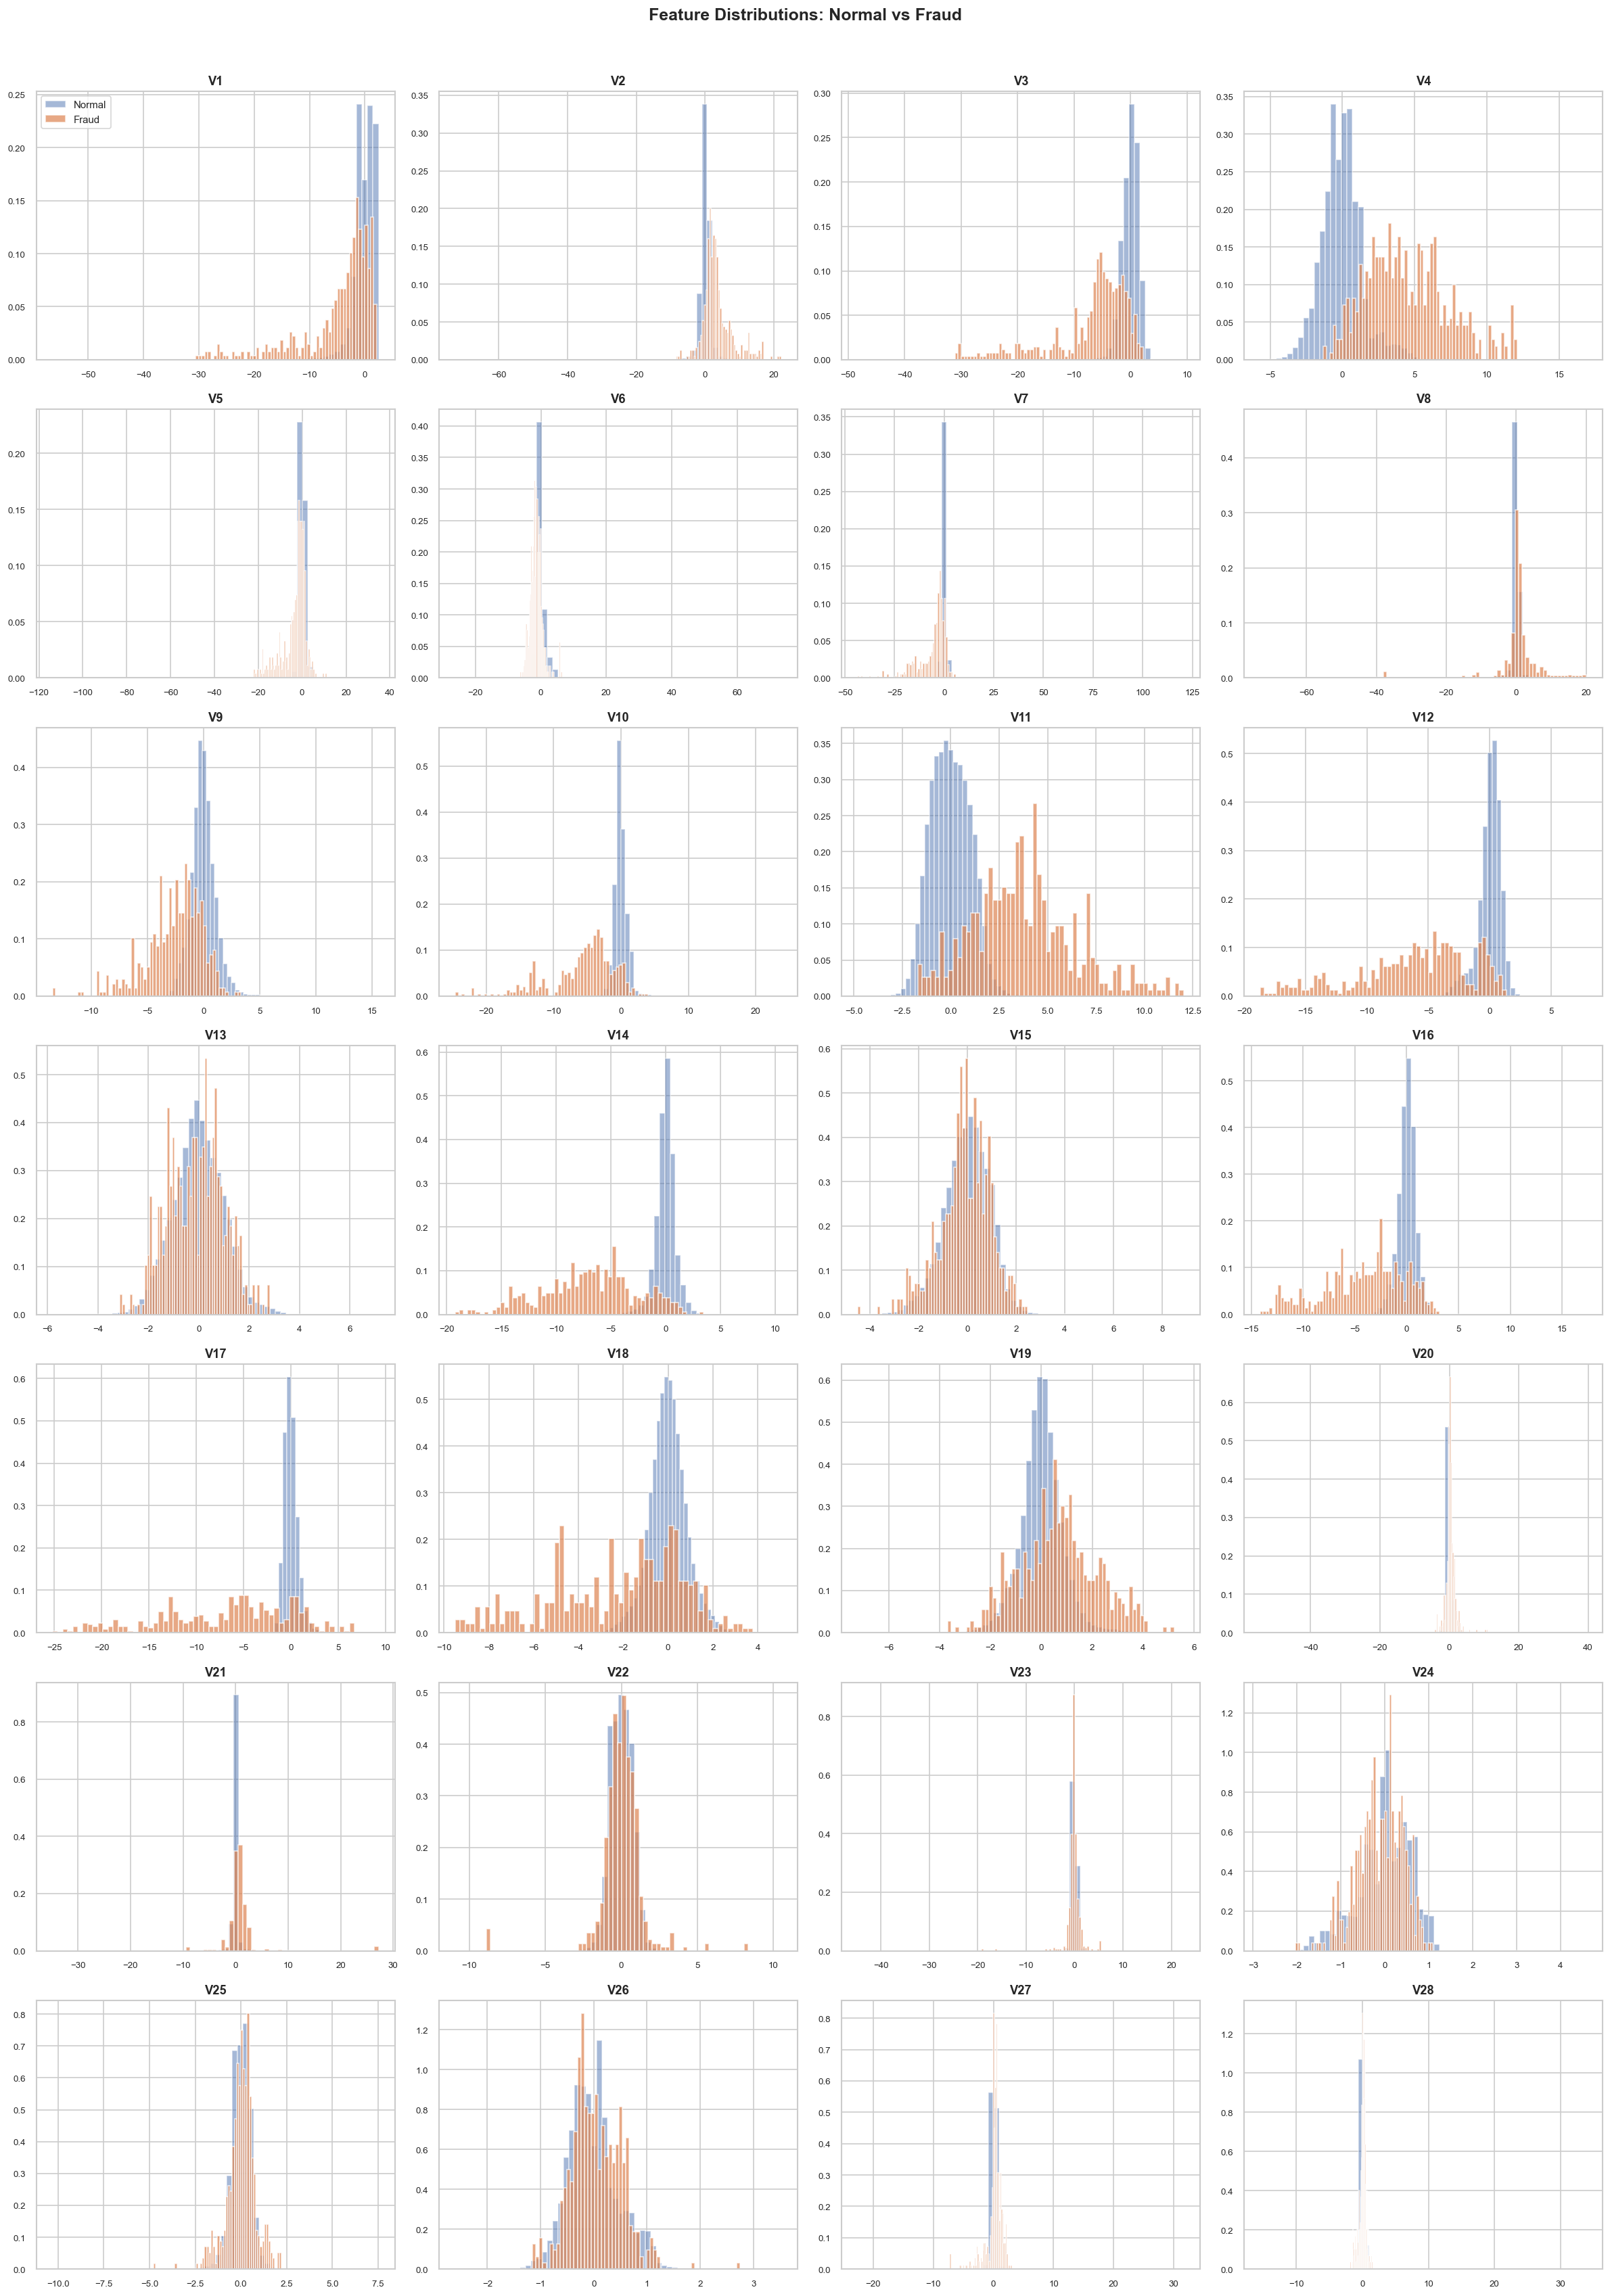

In [11]:
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(v_features):
    axes[i].hist(df[df['Class'] == 0][col], bins=60, alpha=0.5, color='#4C72B0', label='Normal', density=True)
    axes[i].hist(df[df['Class'] == 1][col], bins=60, alpha=0.7, color='#DD8452', label='Fraud',  density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: Normal vs Fraud', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

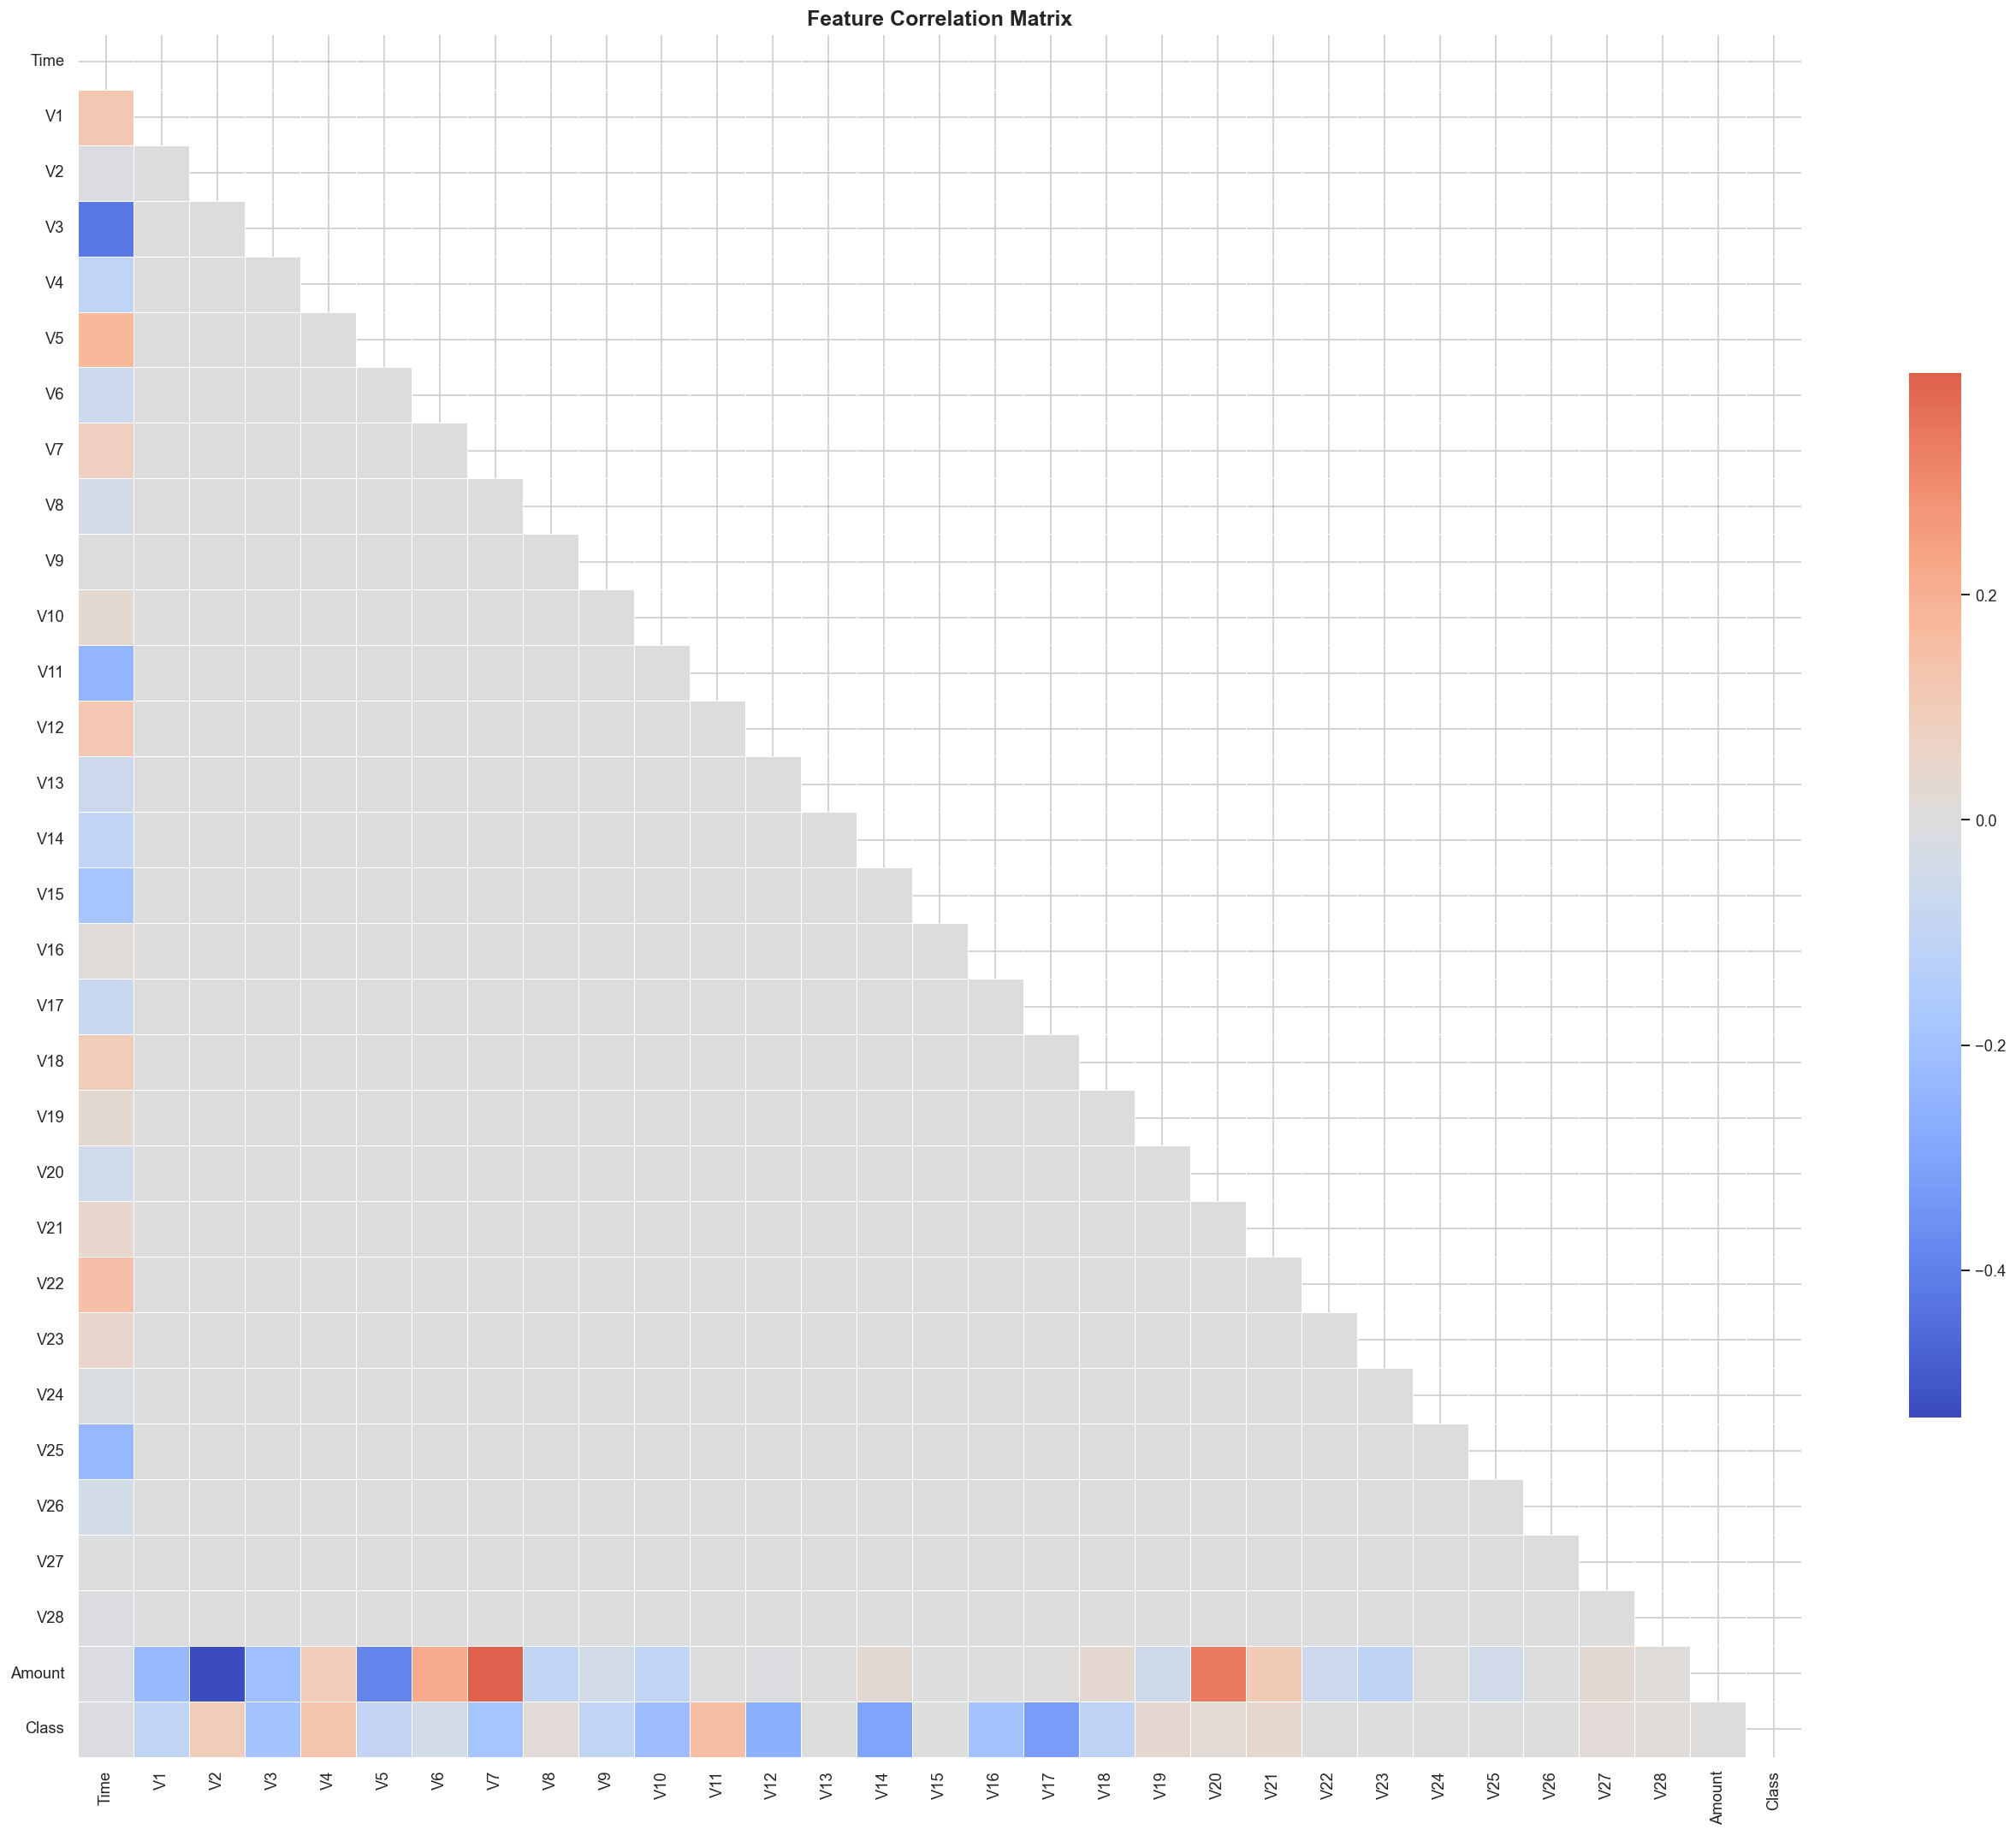

In [12]:
corr = df.corr()

plt.figure(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    square=True,
    cbar_kws={'shrink': 0.6}
)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Top Features Correlated with Fraud

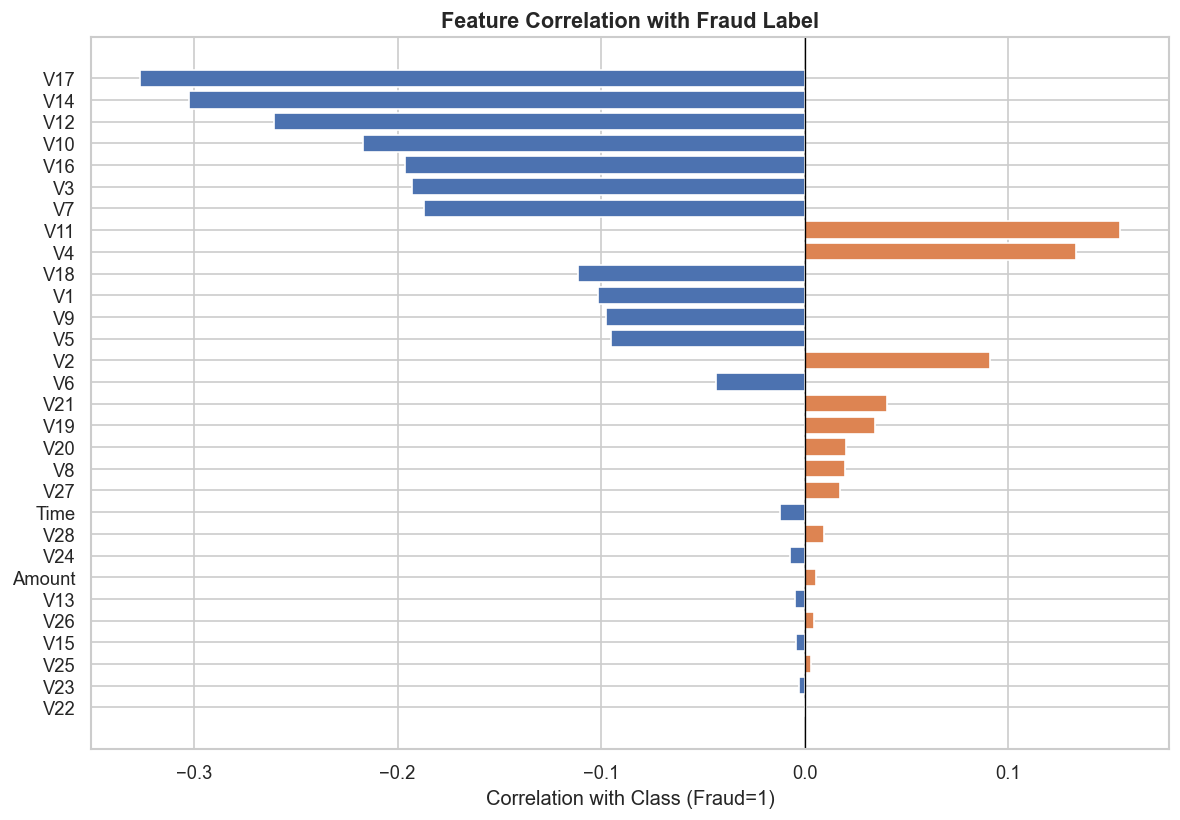


Top 10 features correlated with fraud:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V11    0.1549
V4     0.1334
V18   -0.1115


In [13]:
fraud_corr = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in fraud_corr.values]
bars = plt.barh(fraud_corr.index, fraud_corr.values, color=colors)
plt.xlabel('Correlation with Class (Fraud=1)', fontsize=12)
plt.title('Feature Correlation with Fraud Label', fontsize=13, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features correlated with fraud:')
print(fraud_corr.head(10).round(4).to_string())

## 9. Key Findings Summary

| Finding | Detail |
|---------|--------|
| **Class imbalance** | 99.83% normal, 0.17% fraud — ratio of ~578:1 |
| **No missing values** | Dataset is clean, no imputation needed |
| **Amount** | Fraud transactions tend to be smaller on average |
| **Time** | Fraud is distributed throughout the day; normal shows a dip at night |
| **V features** | Several (V4, V11, V12, V14, V17) show clear separation between classes |
| **V features are uncorrelated** | PCA ensures V1–V28 have near-zero inter-correlation |

### Why SMOTE is Essential
With a 578:1 imbalance, any model trained on raw data will learn to predict "normal" for every transaction and achieve 99.83% accuracy while catching zero fraud. SMOTE (Step 3) will synthetically oversample the fraud class in training data to fix this.

### Why AUC-ROC is the Right Metric
Accuracy is misleading here. We'll use:
- **AUC-ROC** — separability across all thresholds (primary metric)
- **Recall** — what % of actual frauds we catch (catching fraud > avoiding false alarms)
- **Precision** — what % of fraud predictions are correct
- **F1** — balance of precision and recall